In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='Tahoma')
import os
os.makedirs("output/charts", exist_ok=True)


In [3]:
# Constituency 2569
df_con = pd.concat([
    pd.read_csv("output/final_csv/constituency.csv"),
    pd.read_csv("output/final_csv/17_constituency.csv"),
], ignore_index=True)
cand_ref = pd.read_csv("reference/candidates_ref.csv")
num_to_party = dict(zip(cand_ref["หมายเลข"], cand_ref["พรรค"]))
df_con["พรรค"] = df_con["หมายเลข"].map(num_to_party)

# Party list 2569
df_pl_main = pd.read_csv("output/final_csv/party_list.csv").rename(columns={"พรรคการเมือง": "พรรค"})
df_pl_17   = pd.read_csv("output/final_csv/17_party_list.csv")
for df in [df_pl_main, df_pl_17]:
    df["พรรค"] = df["พรรค"].str.replace("^พรรค", "", regex=True)
df_pl = pd.concat([df_pl_main[["พรรค","คะแนน"]], df_pl_17[["พรรค","คะแนน"]]], ignore_index=True)


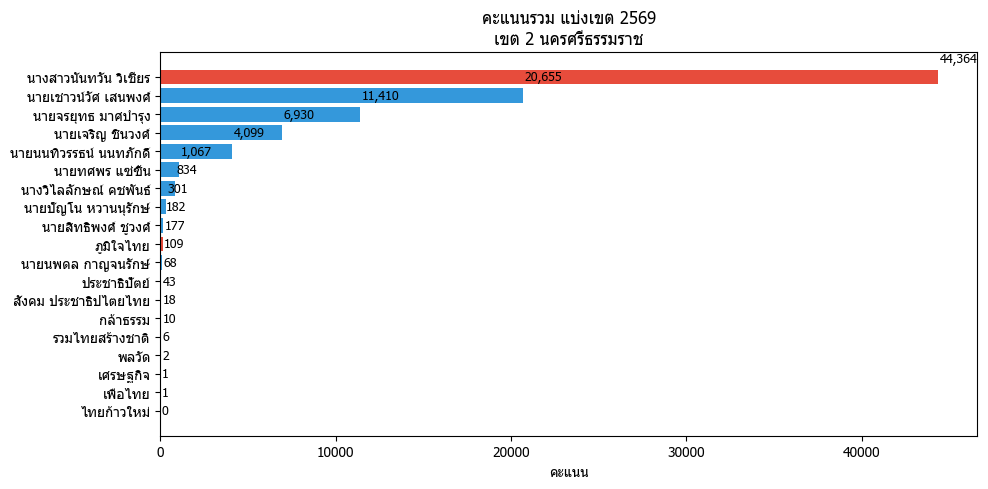

In [ ]:
#Constituency 2569
con_total = df_con.groupby(["ชื่อสกุล","พรรค"])["คะแนน"].sum().reset_index()
con_total = con_total.sort_values("คะแนน", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if p == "ภูมิใจไทย" else "#3498db" for p in con_total["พรรค"]]
ax.barh(con_total["ชื่อสกุล"], con_total["คะแนน"], color=colors)
ax.set_xlabel("คะแนน")
ax.set_title("คะแนนรวม แบ่งเขต 2569\nเขต 2 นครศรีธรรมราช")
for i, (v, name) in enumerate(zip(con_total["คะแนน"], con_total["ชื่อสกุล"])):
    ax.text(v + 100, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("output/charts/01_constituency_2569.png", dpi=150)
plt.show()


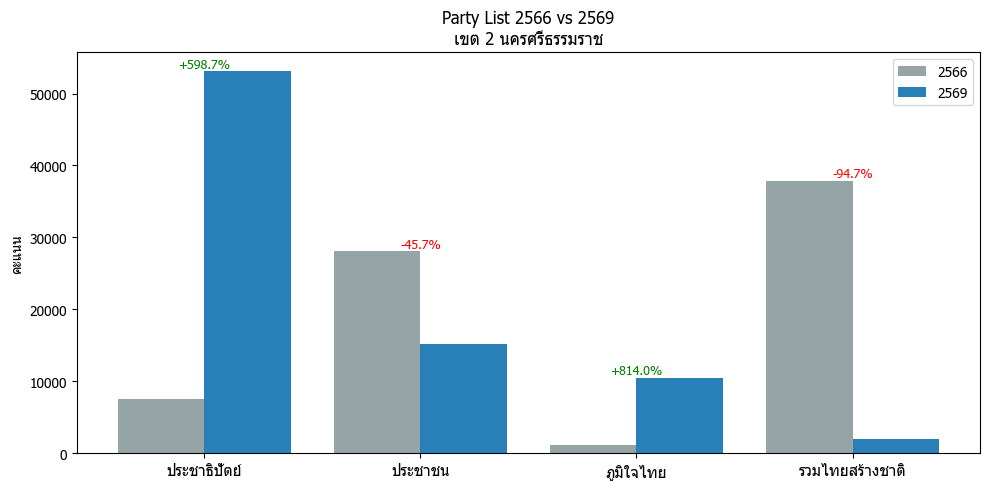

           พรรค  คะแนน_2566  คะแนน_2569  เปลี่ยนแปลง_%
   ประชาธิปัตย์        7599     53094.0          598.7
        ประชาชน       28049     15244.0          -45.7
      ภูมิใจไทย        1145     10465.0          814.0
รวมไทยสร้างชาติ       37891      1990.0          -94.7


In [8]:
#Party List 2566 vs 2569
pl_2566 = pd.DataFrame({
    "พรรค":       ["ประชาธิปัตย์", "ประชาชน", "ภูมิใจไทย", "รวมไทยสร้างชาติ"],
    "คะแนน_2566": [7599, 28049, 1145, 37891]
})
pl_2569 = df_pl.groupby("พรรค")["คะแนน"].sum().reset_index()
pl_2569.columns = ["พรรค", "คะแนน_2569"]

compare = pl_2566.merge(pl_2569, on="พรรค")
compare["เปลี่ยนแปลง_%"] = ((compare["คะแนน_2569"] - compare["คะแนน_2566"]) / compare["คะแนน_2566"] * 100).round(1)
compare = compare.sort_values("คะแนน_2569", ascending=False)

x = range(len(compare))
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar([i - 0.2 for i in x], compare["คะแนน_2566"], width=0.4, label="2566", color="#95a5a6")
b2 = ax.bar([i + 0.2 for i in x], compare["คะแนน_2569"], width=0.4, label="2569", color="#2980b9")
ax.set_xticks(list(x))
ax.set_xticklabels(compare["พรรค"], fontsize=11)
ax.set_ylabel("คะแนน")
ax.set_title("Party List 2566 vs 2569\nเขต 2 นครศรีธรรมราช")
ax.legend()
for i, row in compare.reset_index(drop=True).iterrows():
    pct = row["เปลี่ยนแปลง_%"]
    sign = "+" if pct >= 0 else ""
    color = "green" if pct >= 0 else "red"
    ax.text(i, max(row["คะแนน_2566"], row["คะแนน_2569"]) + 500,
            f"{sign}{pct}%", ha="center", color=color, fontsize=9)

plt.tight_layout()
plt.savefig("output/charts/02_party_list_compare.png", dpi=150)
plt.show()
print(compare[["พรรค","คะแนน_2566","คะแนน_2569","เปลี่ยนแปลง_%"]].to_string(index=False))


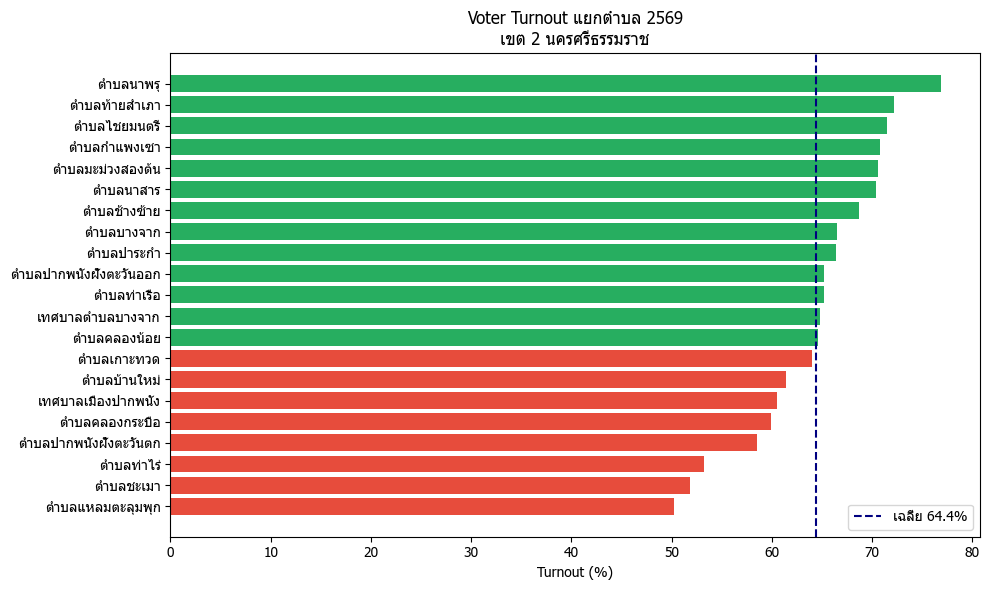

                   ตำบล  ผู้มีสิทธิ  ผู้มาใช้สิทธิ  turnout_%
       ตำบลแหลมตะลุมพุก     16190.0         8130.0       50.2
              ตำบลชะเมา     27580.0        14280.0       51.8
             ตำบลท่าไร่     56460.0        30050.0       53.2
 ตำบลปากพนังฝั่งตะวันตก     44360.0        25930.0       58.5
         ตำบลคลองกระบือ     47350.0        28370.0       59.9
     เทศบาลเมืองปากพนัง    146890.0        88920.0       60.5
           ตำบลบ้านใหม่     30650.0        18830.0       61.4
            ตำบลเกาะทวด     41600.0        26630.0       64.0
           ตำบลคลองน้อย     89560.0        57843.0       64.6
       เทศบาลตำบลบางจาก     14870.0         9640.0       64.8
            ตำบลท่าเรือ    161130.0       105120.0       65.2
ตำบลปากพนังฝั่งตะวันออก     62310.0        40620.0       65.2
            ตำบลป่าระกำ     36860.0        24490.0       66.4
             ตำบลบางจาก     72420.0        48150.0       66.5
           ตำบลช้างซ้าย     99610.0        68400.0       68.7
        

In [7]:
turnout = df_con.groupby("ตำบล").agg(
    ผู้มีสิทธิ=("จำนวนผู้มีสิทธิเลือกตั้ง","sum"),
    ผู้มาใช้สิทธิ=("จำนวนผู้มาแสดงตน","sum"),
).reset_index().dropna()
turnout["turnout_%"] = (turnout["ผู้มาใช้สิทธิ"] / turnout["ผู้มีสิทธิ"] * 100).round(1)
turnout = turnout.sort_values("turnout_%", ascending=True)
avg = turnout["turnout_%"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if v < avg else "#27ae60" for v in turnout["turnout_%"]]
ax.barh(turnout["ตำบล"], turnout["turnout_%"], color=colors)
ax.axvline(avg, color="navy", linestyle="--", label=f"เฉลี่ย {avg:.1f}%")
ax.set_xlabel("Turnout (%)")
ax.set_title("Voter Turnout แยกตำบล 2569\nเขต 2 นครศรีธรรมราช")
ax.legend()
plt.tight_layout()
plt.savefig("output/charts/04_turnout.png", dpi=150)
plt.show()
print(turnout[["ตำบล","ผู้มีสิทธิ","ผู้มาใช้สิทธิ","turnout_%"]].to_string(index=False))
